In [2]:
import matplotlib.pyplot as plt
import sys, pathlib
import time
sys.path.insert(0, str(pathlib.Path("..").resolve()))

In [26]:
import statistics
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

def benchmark(fn, sizes, runs=10):
    """Time fn(n) over a range of board sizes; return {n: [ms, ...]}."""
    results = {}
    for n in sizes:
        times = []
        for _ in range(runs):
            t0 = time.perf_counter()
            fn(n)
            times.append((time.perf_counter() - t0) * 1000)
        results[n] = times
        print(f"n={n}: median={sorted(times)[len(times)//2]:.1f} ms")
    print("Done!")
    return results

def _compute_stats(results):
    ns = sorted(results)
    means = [statistics.mean(results[n]) for n in ns]
    stds  = [statistics.stdev(results[n]) for n in ns]
    return np.array(ns, dtype=float), np.array(means), np.array(stds)

def plot_runtime(results, title):
    ns_arr, means_arr, _ = _compute_stats(results)
    lows  = np.array([min(results[n]) for n in sorted(results)])
    highs = np.array([max(results[n]) for n in sorted(results)])

    fig, ax = plt.subplots()
    ax.fill_between(ns_arr, lows, highs, alpha=0.2, color="tab:blue", label="range (min–max)")
    ax.plot(ns_arr, means_arr, marker="o", color="tab:blue", label="mean")
    ax.set_xlabel("board size n")
    ax.set_ylabel("time (ms)")
    ax.set_title(title)
    ax.set_ylim(bottom=0)
    ax.legend()
    plt.show()

def plot_growth(results, title):
    ns_arr, means_arr, _ = _compute_stats(results)
    lows  = np.array([min(results[n]) for n in sorted(results)])
    highs = np.array([max(results[n]) for n in sorted(results)])

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

    ax1.set_xscale("log"); ax1.set_yscale("log")
    ax1.fill_between(ns_arr, lows, highs, alpha=0.2, color="tab:blue")
    ax1.plot(ns_arr, means_arr, marker="o", color="tab:blue")
    ax1.set_title(f"log-log (straight = polynomial) {title}")
    ax1.set_xlabel("n"); ax1.set_ylabel("ms")

    ax2.set_yscale("log")
    ax2.fill_between(ns_arr, lows, highs, alpha=0.2, color="tab:blue")
    ax2.plot(ns_arr, means_arr, marker="o", color="tab:blue")
    ax2.set_title(f"log-linear (straight = exponential) {title}")
    ax2.set_xlabel("n")

    plt.tight_layout()
    plt.show()


def fit_growth(results):
    ns_arr, means_arr, _ = _compute_stats(results)
    log_ns    = np.log(ns_arr)
    log_means = np.log(means_arr)

    r_poly = stats.pearsonr(log_ns, log_means).statistic ** 2
    r_exp  = stats.pearsonr(ns_arr, log_means).statistic ** 2

    slope, _ = np.polyfit(ns_arr, log_means, 1)
    verdict = "exponential" if r_exp > r_poly else "polynomial"

    print(f"R² log-log (polynomial):     {r_poly:.4f}")
    print(f"R² log-linear (exponential): {r_exp:.4f}")
    print(f"verdict: {verdict}, ~{np.exp(slope):.2f}x per +1 n")


# Runtimes
What is the big O of our algorithms?

In [4]:
# Gen Single
from gensingle import generate

results_single = benchmark(generate, range(5, 14))

n=5: median=0.9 ms
n=6: median=1.0 ms
n=7: median=6.9 ms
n=8: median=6.2 ms
n=9: median=16.4 ms
n=10: median=13.7 ms
n=11: median=81.8 ms
n=12: median=85.9 ms
n=13: median=402.7 ms
Done!


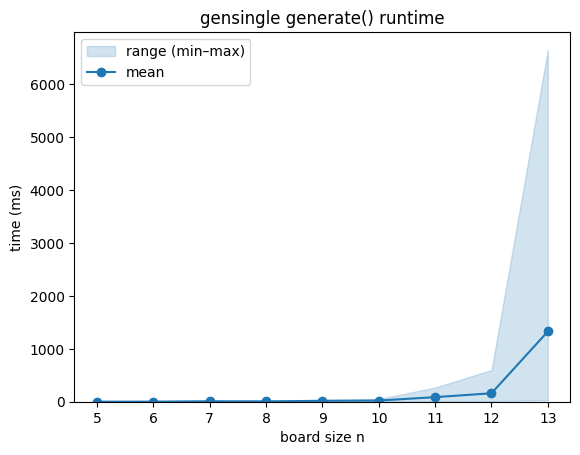

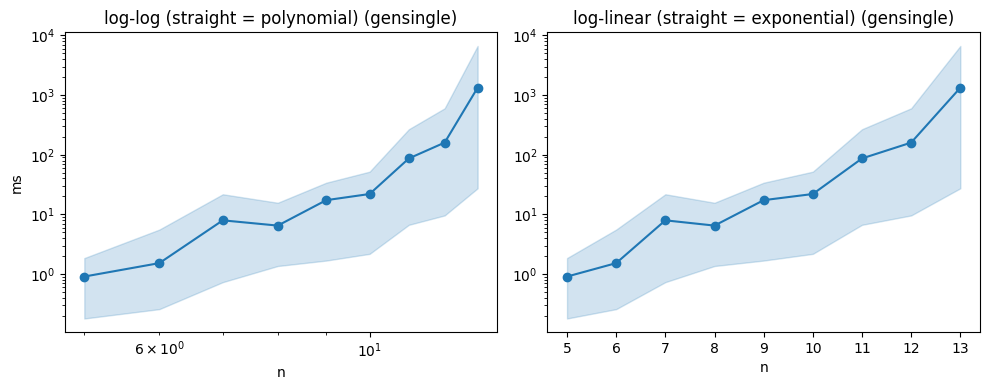

R² log-log (polynomial):     0.9040
R² log-linear (exponential): 0.9477
verdict: exponential, ~2.27x per +1 n


In [27]:
plot_runtime(results_single, "gensingle generate() runtime")
plot_growth(results_single, "(gensingle)")
fit_growth(results_single)

In [6]:
# Gen Double
from gendouble import generate

results_double = benchmark(generate, range(8, 13))

n=8: median=175.6 ms
n=9: median=69.5 ms
n=10: median=44.5 ms
n=11: median=242.7 ms
n=12: median=2487.3 ms
Done!


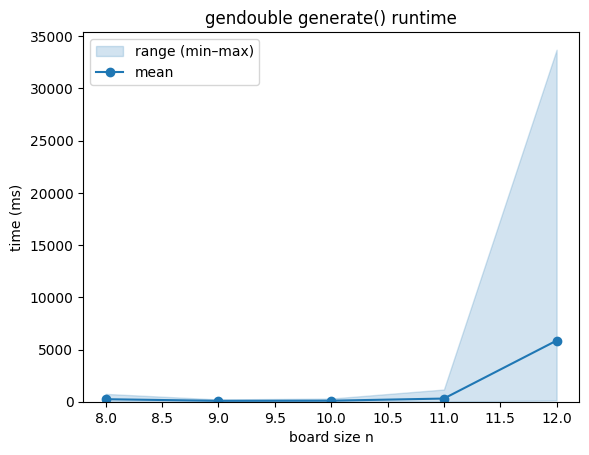

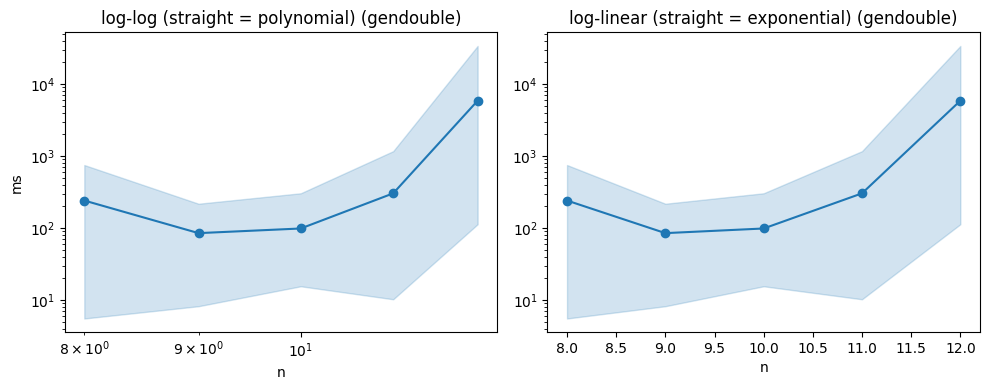

R² log-log (polynomial):     0.4426
R² log-linear (exponential): 0.5017
verdict: exponential, ~2.15x per +1 n


In [28]:
plot_runtime(results_double, "gendouble generate() runtime")
plot_growth(results_double, "(gendouble)")
fit_growth(results_double)


In [8]:
# Gen Double
from maker_flood import generate_puzzle

results_flood = benchmark(generate_puzzle, range(5, 9))

n=5: median=15.6 ms
n=6: median=80.9 ms
n=7: median=738.9 ms
n=8: median=3331.7 ms
Done!


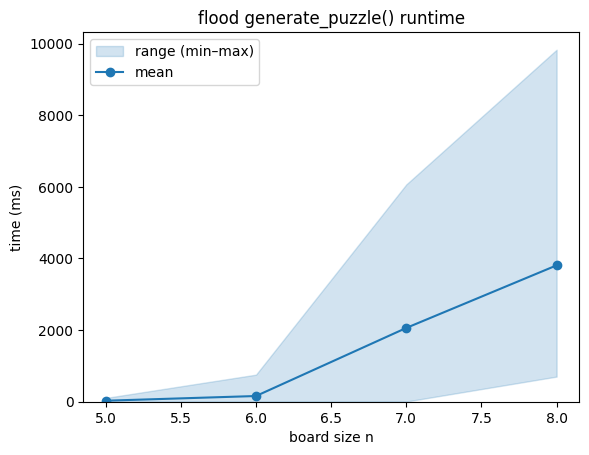

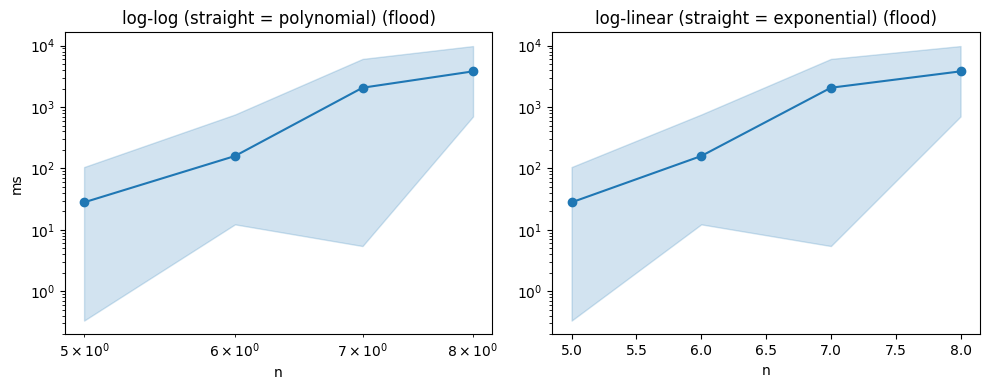

R² log-log (polynomial):     0.9686
R² log-linear (exponential): 0.9554
verdict: polynomial, ~5.64x per +1 n


In [29]:
plot_runtime(results_flood, "flood generate_puzzle() runtime")
plot_growth(results_flood, "(flood)")
fit_growth(results_flood)


In [30]:
# Compare all generators per board size (mean ± stdev, ms)
comparison = {
    "single": results_single,
    "double": results_double,
    "flood":  results_flood,
}
shared_sizes = range(5, 13)

def cell(results, n):
    if not results or n not in results or len(results[n]) < 2:
        return "n/a"
    return f"{statistics.mean(results[n]):.1f}"

header = f"{'n':<4}" + "".join(f"{name:>18}" for name in comparison)
print(header)
print("-" * len(header))
for n in shared_sizes:
    row = f"{n:<4}" + "".join(f"{cell(results, n):>18}" for results in comparison.values())
    print(row)


n               single            double             flood
----------------------------------------------------------
5                  0.9               n/a              28.0
6                  1.5               n/a             159.3
7                  8.0               n/a            2060.2
8                  6.5             241.0            3807.3
9                 17.3              85.0               n/a
10                22.0              98.6               n/a
11                86.7             303.3               n/a
12               159.8            5854.3               n/a
